# **AI Waste Sorting System (Great for Sustainability)**

A computer vision system that classifies waste into categories.

**Classes**:
- Plastic
- Metal
- Paper
- Glass
- Organic waste
<br/>

**Objective**:
Built an AI system to assist automated recycling by classifying waste images using CNN models.
<br/>

**What makes it impressive**

Instead of basic classification, you can add:
- **Real-time classification with webcam**
- Confidence visualization
- Explainability with Grad-CAM
- Edge deployment simulation
- **3D simulation**
<br/>

**Dataset**
- [TrashNet dataset](https://github.com/garythung/trashnet/blob/master/data/dataset-resized.zip)
- TACO dataset

In [ ]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
## getting the dataset
import requests
import zipfile
import shutil
from pathlib import Path

# 1. Setup paths
data_path = Path("data/")
image_path = data_path / "images"

# 2. Download (only if it doesn't exist to save time)
zip_file = data_path / "dataset-resized.zip"
if not zip_file.is_file():
    data_path.mkdir(parents = True, exist_ok = True)
    print("Downloading trash net dataset...")
    with open(zip_file, "wb") as f:
        request = requests.get("https://github.com/garythung/trashnet/raw/master/data/dataset-resized.zip")
        f.write(request.content)
else:
    print(f"{zip_file} already exists, skipping download.")

# 3. Extract and Organize
if not image_path.is_dir():
    print("Unzipping and organizing...")
    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        # Extract to data/ temporarily
        zip_ref.extractall(data_path)

    # The zip contains a folder called 'dataset-resized'. Let's rename it to 'images'
    # We use shutil.move to handle the renaming/moving easily
    temp_folder = data_path / "dataset-resized"
    if temp_folder.exists():
        temp_folder.rename(image_path)

    # 4. Cleanup: Remove the zip and the annoying __MACOSX folder
    zip_file.unlink() # deletes the zip
    macosx_folder = data_path / "__MACOSX"
    if macosx_folder.exists():
        shutil.rmtree(macosx_folder)

    print(f"Done! Your data is in {image_path}")
else:
    print(f"{image_path} already exists.")

Unzipping and organizing...
Done! Your data is in data/images


In [ ]:
!pip install split-folders

In [ ]:
## splitting dataset dir into train/ and test/
import splitfolders

# 1. Define your paths
input_folder = "data/images" # Where my images are now
output_folder = "data/split_data" # Where the train/test folders will go

# 2. Split the data
# ratio=(.8, .2) means 80% Train, 20% Test
splitfolders.ratio(input_folder, output = output_folder, seed = 42, ratio = (.8,.2))

print("Successfully split data into train and test folders!")

Copying files: 2527 files [00:00, 3575.86 files/s]

Successfully split data into train and test folders!


In [ ]:
## becoming one with the data(preparation and data exploration)
import os

def walk_through_dir(dir_path):
  '''
  walks through dir_path returning its contents
  '''
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [ ]:
data_path = Path("data/")
image_path = data_path / "split_data"
walk_through_dir(image_path)

There are 3 directories and 0 images in 'data/split_data'.
There are 6 directories and 0 images in 'data/split_data/train'.
There are 0 directories and 385 images in 'data/split_data/train/plastic'.
There are 0 directories and 322 images in 'data/split_data/train/cardboard'.
There are 0 directories and 328 images in 'data/split_data/train/metal'.
There are 0 directories and 109 images in 'data/split_data/train/trash'.
There are 0 directories and 475 images in 'data/split_data/train/paper'.
There are 0 directories and 400 images in 'data/split_data/train/glass'.
There are 0 directories and 0 images in 'data/split_data/.ipynb_checkpoints'.
There are 6 directories and 0 images in 'data/split_data/test'.
There are 0 directories and 97 images in 'data/split_data/test/plastic'.
There are 0 directories and 81 images in 'data/split_data/test/cardboard'.
There are 0 directories and 82 images in 'data/split_data/test/metal'.
There are 0 directories and 28 images in 'data/split_data/test/trash'.


In [ ]:
# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/split_data/train'), PosixPath('data/split_data/test'))

Random image path: data/split_data/train/metal/metal75.jpg
Image class: metal
Image height: 384
Image width: 512


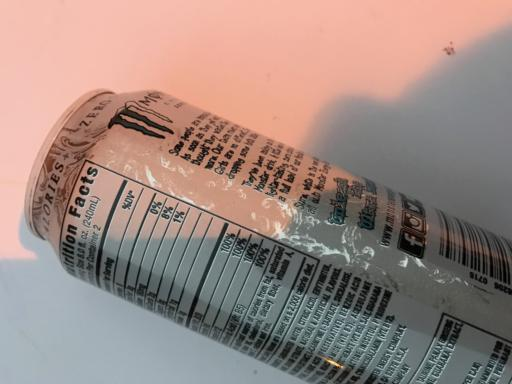

In [ ]:
## visualizing image
import random
from PIL import Image

# 1. Get all image paths
image_path_list = list(train_dir.glob("*/*.jpg"))

# 2. Pick a random image path
random_image_path = random.choice(image_path_list)

# 3. Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem

# 4. Open image
img = Image.open(random_image_path)

# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img


(np.float64(-0.5), np.float64(511.5), np.float64(383.5), np.float64(-0.5))

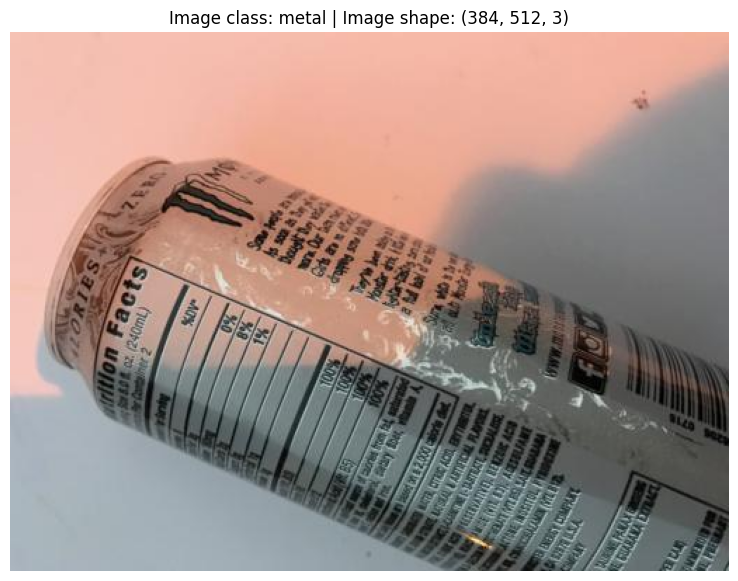

In [ ]:
# visualize data in matplotlib
import numpy as np
import matplotlib.pyplot as plt

# turn the image into an array
img_as_array = np.asarray(img)

# plot the image with matplotlib
plt.figure(figsize = (10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape}")
plt.axis(False)

array([[[246, 194, 180],
        [246, 194, 180],
        [246, 194, 180],
        ...,
        [243, 177, 155],
        [243, 177, 155],
        [243, 177, 155]],

       [[246, 194, 180],
        [246, 194, 180],
        [246, 194, 180],
        ...,
        [243, 177, 155],
        [243, 177, 155],
        [243, 177, 155]],

       [[246, 194, 180],
        [246, 194, 180],
        [246, 194, 180],
        ...,
        [243, 177, 155],
        [243, 177, 155],
        [243, 177, 155]],

       ...,

       [[172, 182, 192],
        [171, 181, 191],
        [171, 181, 191],
        ...,
        [ 57,  69,  67],
        [ 52,  64,  62],
        [125, 137, 135]],

       [[172, 182, 192],
        [172, 182, 192],
        [171, 181, 191],
        ...,
        [ 50,  65,  62],
        [ 89, 104, 101],
        [133, 148, 145]],

       [[172, 182, 192],
        [172, 182, 192],
        [172, 182, 192],
        ...,
        [ 51,  66,  63],
        [119, 134, 131],
        [124, 139, 136]]], dtype=uint8)
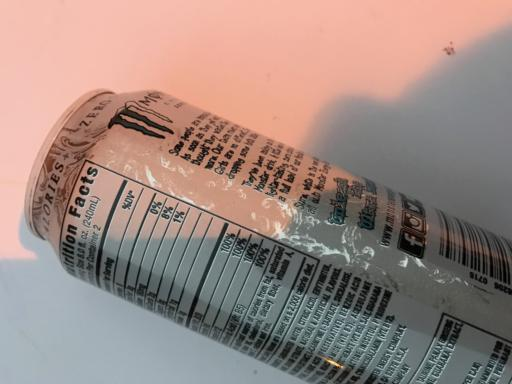

In [ ]:
img_as_array

In [ ]:
## transforming data
# before we can use our custom image data with Pytorch

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# transform
data_transform = transforms.Compose({
    transforms.Resize(size = (64, 64)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.ToTensor()
})

In [ ]:
data_transform(img).shape, data_transform(img).dtype

(torch.Size([3, 64, 64]), torch.float32)

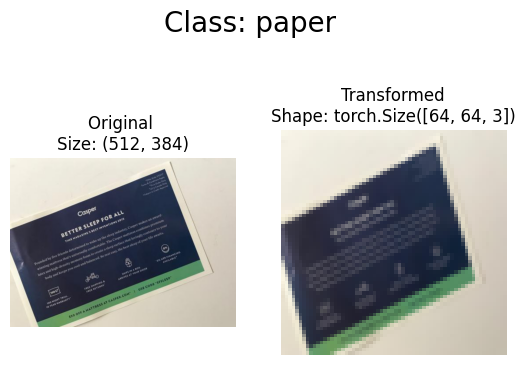

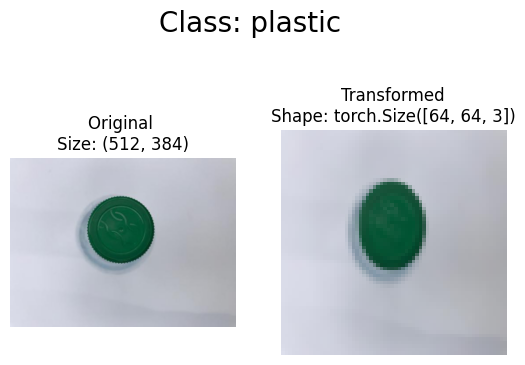

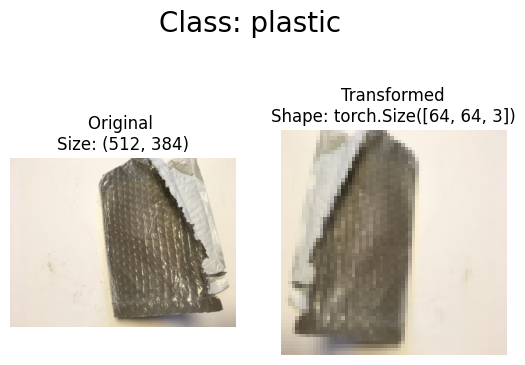

In [ ]:
def plot_transformed_images(image_paths, transform, n = 3, seed = 42):
  '''
  selects random images from a path of images and loads/transforms them then
  plots the original vs the transformed version.
  '''
  if seed:
    random.seed(seed)
  random_image_paths = random.sample(image_paths, k = n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(nrows = 1, ncols = 2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original \nSize: {f.size}")
      ax[0].axis("off")

      # Transform and plot target image
      #transformed_image = transform(f) # note we will need to change shape for matplotlib
      transformed_image = transform(f).permute(1, 2, 0) # change the shape
      ax[1].imshow(transformed_image) # add imshow here
      ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
      ax[1].axis("off")

      fig.suptitle(f"Class: {image_path.parent.stem}", fontsize = 20)

plot_transformed_images(image_paths = image_path_list,
                        transform = data_transform,
                        n = 3,
                        seed = 42)

In [ ]:
## Loading custom dataset image
from torchvision import datasets

train_data = datasets.ImageFolder(
    root = train_dir,
    transform = data_transform,
    target_transform = None
)

test_data = datasets.ImageFolder(
    root = test_dir,
    transform = data_transform
)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 2019
     Root location: data/split_data/train
     StandardTransform
 Transform: Compose(
                ToTensor()
                RandomHorizontalFlip(p=0.5)
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
            ),
 Dataset ImageFolder
     Number of datapoints: 508
     Root location: data/split_data/test
     StandardTransform
 Transform: Compose(
                ToTensor()
                RandomHorizontalFlip(p=0.5)
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
            ))

In [ ]:
# get class name as a list
class_names = train_data.classes
class_names

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

In [ ]:
# Get class names as dict
class_dict = train_data.class_to_idx
class_dict

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}

In [ ]:
len(train_data), len(test_data)

(2019, 508)

In [ ]:
train_data.targets

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [ ]:
train_data[0]

(tensor([[[0.9568, 0.9531, 0.9537,  ..., 0.8262, 0.8464, 0.8520],
          [0.9552, 0.9520, 0.9497,  ..., 0.8244, 0.8399, 0.8493],
          [0.9451, 0.9429, 0.9536,  ..., 0.8193, 0.8300, 0.8389],
          ...,
          [0.6949, 0.6809, 0.6555,  ..., 0.4452, 0.4422, 0.4323],
          [0.6995, 0.6880, 0.6617,  ..., 0.4490, 0.4466, 0.4436],
          [0.7201, 0.6917, 0.6414,  ..., 0.4471, 0.4433, 0.4465]],
 
         [[0.7999, 0.7957, 0.7934,  ..., 0.6537, 0.6739, 0.6795],
          [0.7983, 0.7947, 0.7895,  ..., 0.6519, 0.6673, 0.6767],
          [0.7938, 0.7903, 0.7939,  ..., 0.6508, 0.6615, 0.6704],
          ...,
          [0.5518, 0.5493, 0.5447,  ..., 0.3506, 0.3446, 0.3342],
          [0.5509, 0.5551, 0.5488,  ..., 0.3543, 0.3490, 0.3455],
          [0.5715, 0.5588, 0.5286,  ..., 0.3525, 0.3457, 0.3484]],
 
         [[0.6627, 0.6609, 0.6733,  ..., 0.5400, 0.5602, 0.5658],
          [0.6611, 0.6599, 0.6694,  ..., 0.5381, 0.5536, 0.5630],
          [0.6549, 0.6541, 0.6736,  ...,

In [ ]:
img, label = train_data[0][0], train_data[0][1]
img

tensor([[[0.8520, 0.8464, 0.8262,  ..., 0.9537, 0.9531, 0.9568],
         [0.8493, 0.8399, 0.8244,  ..., 0.9497, 0.9520, 0.9552],
         [0.8389, 0.8300, 0.8193,  ..., 0.9536, 0.9429, 0.9451],
         ...,
         [0.4323, 0.4422, 0.4452,  ..., 0.6555, 0.6809, 0.6949],
         [0.4436, 0.4466, 0.4490,  ..., 0.6617, 0.6880, 0.6995],
         [0.4465, 0.4433, 0.4471,  ..., 0.6414, 0.6917, 0.7201]],

        [[0.6795, 0.6739, 0.6537,  ..., 0.7934, 0.7957, 0.7999],
         [0.6767, 0.6673, 0.6519,  ..., 0.7895, 0.7947, 0.7983],
         [0.6704, 0.6615, 0.6508,  ..., 0.7939, 0.7903, 0.7938],
         ...,
         [0.3342, 0.3446, 0.3506,  ..., 0.5447, 0.5493, 0.5518],
         [0.3455, 0.3490, 0.3543,  ..., 0.5488, 0.5551, 0.5509],
         [0.3484, 0.3457, 0.3525,  ..., 0.5286, 0.5588, 0.5715]],

        [[0.5658, 0.5602, 0.5400,  ..., 0.6733, 0.6609, 0.6627],
         [0.5630, 0.5536, 0.5381,  ..., 0.6694, 0.6599, 0.6611],
         [0.5553, 0.5468, 0.5381,  ..., 0.6736, 0.6541, 0.

In [ ]:
label

0

In [ ]:
class_names[label]

'cardboard'

In [ ]:
print(f"Image tensor:\n {img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Image class: {class_names[label]}")

Image tensor:
 tensor([[[0.8520, 0.8464, 0.8262,  ..., 0.9537, 0.9531, 0.9568],
         [0.8493, 0.8399, 0.8244,  ..., 0.9497, 0.9520, 0.9552],
         [0.8389, 0.8300, 0.8193,  ..., 0.9536, 0.9429, 0.9451],
         ...,
         [0.4323, 0.4422, 0.4452,  ..., 0.6555, 0.6809, 0.6949],
         [0.4436, 0.4466, 0.4490,  ..., 0.6617, 0.6880, 0.6995],
         [0.4465, 0.4433, 0.4471,  ..., 0.6414, 0.6917, 0.7201]],

        [[0.6795, 0.6739, 0.6537,  ..., 0.7934, 0.7957, 0.7999],
         [0.6767, 0.6673, 0.6519,  ..., 0.7895, 0.7947, 0.7983],
         [0.6704, 0.6615, 0.6508,  ..., 0.7939, 0.7903, 0.7938],
         ...,
         [0.3342, 0.3446, 0.3506,  ..., 0.5447, 0.5493, 0.5518],
         [0.3455, 0.3490, 0.3543,  ..., 0.5488, 0.5551, 0.5509],
         [0.3484, 0.3457, 0.3525,  ..., 0.5286, 0.5588, 0.5715]],

        [[0.5658, 0.5602, 0.5400,  ..., 0.6733, 0.6609, 0.6627],
         [0.5630, 0.5536, 0.5381,  ..., 0.6694, 0.6599, 0.6611],
         [0.5553, 0.5468, 0.5381,  ..., 0.6

Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Image permute: torch.Size([64, 64, 3]) -> [height, width, color_channels]


Text(0.5, 1.0, 'cardboard')

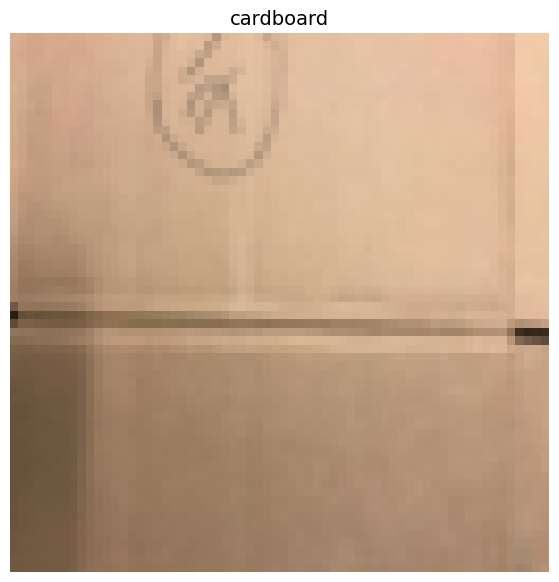

In [ ]:
# rearrange the order dimensions
img_permute = img.permute(1, 2, 0)

# print out different shapes
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute: {img_permute.shape} -> [height, width, color_channels]")

# plot the image
plt.figure(figsize = (10, 7))
plt.imshow(img_permute)
plt.axis(False)
plt.title(class_names[label], fontsize = 14)

In [ ]:
## turning loaded images into DataLoaders
import os
os.cpu_count()

2

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(
    dataset = train_data,
    batch_size = BATCH_SIZE,
    num_workers = 1,
    shuffle = True
)

test_dataloader = DataLoader(
    dataset = test_data,
    batch_size = BATCH_SIZE,
    num_workers = 1,
    shuffle = False
)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7c71e30b1d00>,
 <torch.utils.data.dataloader.DataLoader at 0x7c71e2fe7e90>)

In [ ]:
len(train_dataloader), len(test_dataloader)

(64, 16)

In [ ]:
len(train_data), len(test_data)

(2019, 508)

In [ ]:
img, label = next(iter(train_dataloader))

# Batch size will now be 1, you can change the batch size if you like
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([32])


In [ ]:
## creating model

class ImageClassifier(nn.Module):
  def __init__(self, input_shape: int,
               hidden_units: int,
               output_shape: int) -> None:
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels = input_shape,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 0),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2,
                     stride = 2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 0),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2,
                     stride = 2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = hidden_units,
                  out_features = output_shape)
    )

  def forward(self, x: torch.Tensor):
    x = self.conv_block_1(x)
    print("block 1 => ", x.shape)
    x = self.conv_block_2(x)
    print("block 2 => ", x.shape)
    x = self.classifier(x)
    print("classifier => ", x.shape)

    return x


In [ ]:
torch.manual_seed(42)
model_0 = ImageClassifier(
    input_shape = 3,
    hidden_units = 10,
    output_shape = len(train_data.classes)
)

model_0

ImageClassifier(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=10, out_features=6, bias=True)
  )
)

In [ ]:
## Try a forward pass on a single image (to test the model)

image_batch, label_batch = next(iter(train_dataloader))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [ ]:
model_0(image_batch.to(device))

block 1 =>  torch.Size([32, 10, 30, 30])
block 2 =>  torch.Size([32, 10, 13, 13])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x1690 and 10x6)

In [ ]:
## creating model

class ImageClassifier(nn.Module):
  def __init__(self, input_shape: int,
               hidden_units: int,
               output_shape: int) -> None:
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels = input_shape,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 0),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2,
                     stride = 2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 0),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2,
                     stride = 2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = hidden_units * 13 * 13,
                  out_features = output_shape)
    )

  def forward(self, x: torch.Tensor):
    x = self.conv_block_1(x)
    x = self.conv_block_2(x)
    x = self.classifier(x)

    return x


In [ ]:
torch.manual_seed(42)
model_0 = ImageClassifier(
    input_shape = 3,
    hidden_units = 10,
    output_shape = len(train_data.classes)
)

model_0

ImageClassifier(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=6, bias=True)
  )
)

In [ ]:
model_0(image_batch.to(device))

tensor([[ 3.0717e-02,  9.9656e-04,  2.9048e-02,  1.2989e-05,  4.8891e-04,
          5.0476e-03],
        [ 3.0780e-02,  3.5241e-04,  3.0331e-02, -2.9241e-03,  2.0691e-03,
          4.1229e-03],
        [ 3.0557e-02,  2.2466e-03,  2.9136e-02, -2.0445e-03,  5.1421e-05,
          3.0609e-03],
        [ 3.1525e-02,  1.0047e-03,  2.9713e-02, -1.7429e-03,  7.9747e-04,
          4.6280e-03],
        [ 3.1543e-02,  1.0012e-03,  3.0492e-02, -2.0609e-03, -3.2639e-04,
          4.5109e-03],
        [ 3.2186e-02,  1.8013e-03,  2.8922e-02, -4.4156e-03, -1.7861e-03,
          4.2959e-03],
        [ 3.2201e-02,  9.5959e-04,  3.0509e-02, -2.6127e-03,  1.4308e-04,
          4.1795e-03],
        [ 3.1529e-02,  2.6797e-03,  2.5485e-02, -3.9989e-03, -3.9768e-04,
          2.9897e-03],
        [ 3.0567e-02,  2.2767e-03,  3.0113e-02, -1.5177e-03, -3.7519e-04,
          3.7979e-03],
        [ 3.0393e-02,  4.1197e-03,  2.7731e-02, -3.0269e-03, -6.0996e-04,
          2.8966e-03],
        [ 3.2685e-02,  3.7337e

In [ ]:
# install torchinfo, import if it's available
try:
  import torchinfo
except:
  !pip install torchinfo
  import torchinfo

from torchinfo import summary
summary(model_0, input_size = [1, 3, 64, 64])

Layer (type:depth-idx)                   Output Shape              Param #
ImageClassifier                          [1, 6]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

In [ ]:
# Create train_step()
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
  # Put the model in train mode
  model.train()

  # Setup train loss and train accuracy values
  train_loss, train_acc = 0, 0

  # Loop through data loader data batches
  for batch, (X, y) in enumerate(dataloader):
    # send data to the target device
    X, y = X.to(device), y.to(device)

    # 1. Forward pass
    y_pred = model(X)

    # 2. Calculate the loss
    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    # Calculate accuracy metric
    y_pred_class = torch.argmax(torch.softmax(y_pred, dim = 1), dim = 1)
    train_acc += (y_pred_class == y).sum().item() / len(y_pred)

  # Adjust metrics to get average loss and accuracy per batch
  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)

  return train_loss, train_acc

In [ ]:
# Create a test step
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device = device):
  # Put the model in eval mode
  model.eval()

  # Setup test loss and test accuracy values
  test_loss, test_acc = 0, 0

  # Turn on inference mode
  with torch.inference_mode():
    # Loop through DataLoader batches
    for batch, (X, y) in enumerate(dataloader):
      # Send data to the target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      test_pred_logits = model(X)

      # 2. Calculate the loss
      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      # Calculate the accuracy
      test_pred_labels = test_pred_logits.argmax(dim = 1)
      test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

  # Adjust metrics to get average loss and accuracy per batch
  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)

  return test_loss, test_acc


In [ ]:
## Creating a train() function to combine train_step() and test_step()
from timeit import default_timer as timer
from tqdm.auto import tqdm


def train(epochs: int,
          model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module):

  # 2. Create empty results dictionary
  results = {
      "train_loss": [],
      "train_acc": [],
      "test_loss": [],
      "test_acc": []
  }

  # 3. Loop through training and testing steps for a number of epochs
  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(
                                model = model,
                                dataloader = train_dataloader,
                                loss_fn = loss_fn,
                                optimizer = optimizer,
                            )
    test_loss, test_acc = test_step(
                              model = model,
                              dataloader = test_dataloader,
                              loss_fn = loss_fn,
                              device = device
                          )

    # 4. Print out what's happening
    print(f"Epoch: {epoch} | train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f}% | test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}%")

    # 5. Update the results dictionary
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  # 6. Return the filled  results at the end of the epoch
  return results

In [ ]:
## training
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# set number of epochs
EPOCHS = 10

# recreate an instance of imageClassifier
model_0 = ImageClassifier(
    input_shape = 3,
    hidden_units = 10,
    output_shape = len(train_data.classes)
).to(device)

# setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params = model_0.parameters(),
    lr = 0.001
)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_0
model_0_results = train(model = model_0,
                        train_dataloader = train_dataloader,
                        test_dataloader = test_dataloader,
                        optimizer = optimizer,
                        loss_fn = loss_fn,
                        epochs = EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time - start_time:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0 | train_loss: 1.7319 | train_acc: 0.2318% | test_loss: 1.7324 | test_acc: 0.2324%
Epoch: 1 | train_loss: 1.7217 | train_acc: 0.2178% | test_loss: 1.6915 | test_acc: 0.2324%
Epoch: 2 | train_loss: 1.6472 | train_acc: 0.3091% | test_loss: 1.6422 | test_acc: 0.2812%
Epoch: 3 | train_loss: 1.5547 | train_acc: 0.3324% | test_loss: 1.5566 | test_acc: 0.3672%
Epoch: 4 | train_loss: 1.5194 | train_acc: 0.3823% | test_loss: 1.6146 | test_acc: 0.3477%
Epoch: 5 | train_loss: 1.4835 | train_acc: 0.3958% | test_loss: 1.5058 | test_acc: 0.3887%
Epoch: 6 | train_loss: 1.4380 | train_acc: 0.4105% | test_loss: 1.4459 | test_acc: 0.4088%
Epoch: 7 | train_loss: 1.4270 | train_acc: 0.4214% | test_loss: 1.4568 | test_acc: 0.3482%
Epoch: 8 | train_loss: 1.3857 | train_acc: 0.4408% | test_loss: 1.4469 | test_acc: 0.3677%
Epoch: 9 | train_loss: 1.4356 | train_acc: 0.4259% | test_loss: 1.4568 | test_acc: 0.3831%
Total training time: 184.557 seconds


In [ ]:
model_0_results

{'train_loss': [1.7319348193705082,
  1.721685640513897,
  1.647172063589096,
  1.5547320768237114,
  1.5193781591951847,
  1.4834687430411577,
  1.4380270708352327,
  1.4270132491365075,
  1.3857203125953674,
  1.435596153140068],
 'train_acc': [0.23177083333333334,
  0.2177734375,
  0.30908203125,
  0.3323567708333333,
  0.38232421875,
  0.3958333333333333,
  0.4104817708333333,
  0.42138671875,
  0.4407552083333333,
  0.4259440104166667],
 'test_loss': [1.73237656801939,
  1.6914816722273827,
  1.6422246098518372,
  1.5566486418247223,
  1.6145579740405083,
  1.5058134272694588,
  1.4459374882280827,
  1.4568211548030376,
  1.4469074308872223,
  1.4568371921777725],
 'test_acc': [0.232421875,
  0.232421875,
  0.28125,
  0.3671875,
  0.34765625,
  0.388671875,
  0.4087611607142857,
  0.3482142857142857,
  0.3677455357142857,
  0.38309151785714285]}

In [ ]:
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [ ]:
from typing import Dict, List

def plot_loss_curves(results: Dict[str, List[float]]):
  ''' Plot training curves of a result dictionary '''
  # Get the loss values of the results dictionary(training and tes)
  loss = results["train_loss"]
  test_loss = results["test_loss"]

  # Get the accuracy values of the results dictionary  (training and test)
  accuracy = results["train_acc"]
  test_accuracy = results["test_acc"]

  # Figure out how many epochs there were
  epochs = range(len(results["train_loss"]))

  # Setup a plot
  plt.figure(figsize = (15, 7))

  # Plot the loss
  plt.subplot(1, 2, 1)
  plt.plot(epochs, loss, label = "train_loss")
  plt.plot(epochs, test_loss, label = "test_loss")
  plt.title("loss")
  plt.xlabel("epochs")
  plt.legend()

  # Plot the accuracy
  plt.subplot(1, 2, 2)
  plt.plot(epochs, accuracy, label = "train_accuracy")
  plt.plot(epochs, test_accuracy, label = "test_accuracy")
  plt.title("accuracy")
  plt.xlabel("epochs")
  plt.legend()

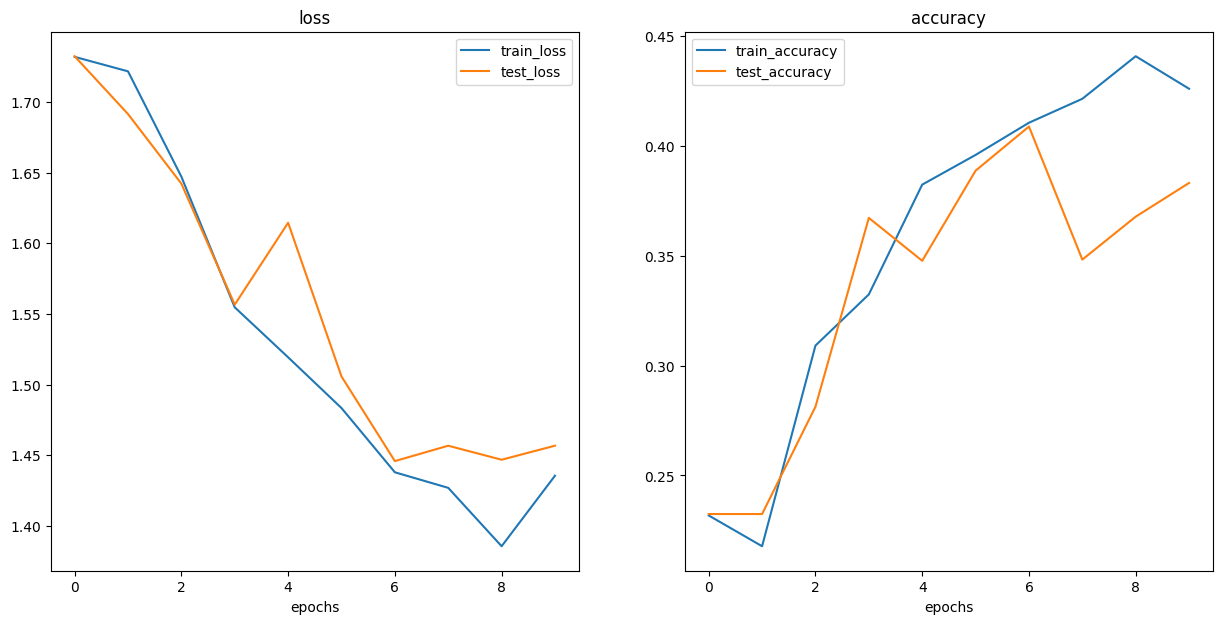

In [ ]:
plot_loss_curves(model_0_results)

In [ ]:
!pip install split-folders

In [ ]:
###

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

import requests
import zipfile
import shutil
from pathlib import Path
import splitfolders

from timeit import default_timer as timer
from tqdm.auto import tqdm


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
## getting the dataset

data_path = Path("data/")
image_path = data_path / "images"

zip_file = data_path / "dataset-resized.zip"
if not zip_file.is_file():
    data_path.mkdir(parents = True, exist_ok = True)
    print("Downloading trash net dataset...")
    with open(zip_file, "wb") as f:
        request = requests.get("https://github.com/garythung/trashnet/raw/master/data/dataset-resized.zip")
        f.write(request.content)
else:
    print(f"{zip_file} already exists, skipping download.")

if not image_path.is_dir():
    print("Unzipping and organizing...")
    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall(data_path)

    temp_folder = data_path / "dataset-resized"
    if temp_folder.exists():
        temp_folder.rename(image_path)

    zip_file.unlink()
    macosx_folder = data_path / "__MACOSX"
    if macosx_folder.exists():
        shutil.rmtree(macosx_folder)

    print(f"Done! Your data is in {image_path}")
else:
    print(f"{image_path} already exists.")

Unzipping and organizing...
Done! Your data is in data/images


In [ ]:
## splitting dataset dir into train/ and test/

input_folder = "data/images"
output_folder = "data/split_data"

splitfolders.ratio(input_folder, output = output_folder, seed = 42, ratio = (.8,.2))

print("Successfully split data into train and test folders!")

Copying files: 2527 files [00:01, 1367.33 files/s]

Successfully split data into train and test folders!


In [ ]:
## transform

data_transform = transforms.Compose({
    transforms.Resize(size = (64, 64)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.RandomRotation(5),
    transforms.ToTensor()
})

In [ ]:
data_transform

Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    RandomRotation(degrees=[-5.0, 5.0], interpolation=nearest, expand=False, fill=0)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
)

In [ ]:
## Loading custom dataset image

train_data = datasets.ImageFolder(
    root = "data/split_data/train",
    transform = data_transform,
    target_transform = None
)

test_data = datasets.ImageFolder(
    root = "data/split_data/test",
    transform = data_transform,
)

In [ ]:
train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 2019
     Root location: data/split_data/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomRotation(degrees=[-5.0, 5.0], interpolation=nearest, expand=False, fill=0)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 508
     Root location: data/split_data/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomRotation(degrees=[-5.0, 5.0], interpolation=nearest, expand=False, fill=0)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [ ]:
class_names = train_data.classes
class_names

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

In [ ]:
class_dict = train_data.class_to_idx
class_dict

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}

In [ ]:
len(train_data), len(test_data)

(2019, 508)

In [ ]:
train_data[0]

(tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.8392, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.8392, 0.0000, 0.0000],
          [0.9529, 0.9529, 0.8980,  ..., 0.8353, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.6941,  ..., 0.4392, 0.4471, 0.4471],
          [0.0000, 0.0000, 0.6980,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.6941,  ..., 0.0000, 0.0000, 0.0000]],
 
         [[0.0000, 0.0000, 0.0000,  ..., 0.6706, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.6784, 0.0000, 0.0000],
          [0.7922, 0.7882, 0.7294,  ..., 0.6745, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.5608,  ..., 0.3569, 0.3529, 0.3529],
          [0.0000, 0.0000, 0.5647,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.5529,  ..., 0.0000, 0.0000, 0.0000]],
 
         [[0.0000, 0.0000, 0.0000,  ..., 0.5569, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.5608, 0.0000, 0.0000],
          [0.6745, 0.6706, 0.6118,  ...,

In [ ]:
img, label = train_data[0][0], train_data[0][1]

In [ ]:
img.shape

torch.Size([3, 64, 64])

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

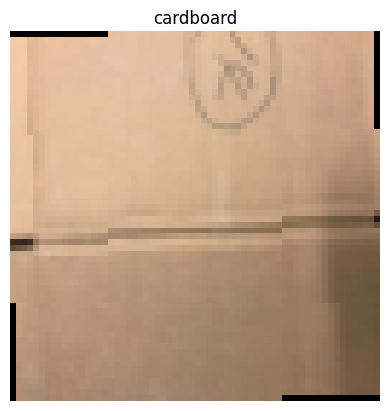

In [ ]:
plt.imshow(img.permute(1, 2, 0))
plt.title(class_names[label])
plt.axis(False)

In [ ]:
## turning loaded images into DataLoaders

train_dataloader = DataLoader(
    train_data,
    batch_size = 32,
    shuffle = True,
    num_workers = 1
)

test_dataloader = DataLoader(
    dataset = test_data,
    batch_size = 32,
    shuffle = False,
    num_workers = 1
)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7fd2d28e87d0>,
 <torch.utils.data.dataloader.DataLoader at 0x7fd2d5561df0>)

In [ ]:
len(train_dataloader), len(test_dataloader)

(64, 16)

In [ ]:
img, label = next(iter(train_dataloader))
print(f"Image shape: {img.shape}")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([32, 3, 64, 64])
Label shape: torch.Size([32])


In [ ]:
class WasteCNN_V0(nn.Module):
  def __init__(self, input_shape: int,
               hidden_units: int,
               output_shape: int) -> None:
    super().__init__()
    self.conv_layer_1 = nn.Conv2d(in_channels = input_shape,
                                  out_channels = hidden_units,
                                  kernel_size = 3,
                                  stride = 1,
                                  padding = 1)
    self.conv_layer_2 = nn.Conv2d(in_channels = hidden_units,
                                  out_channels = hidden_units,
                                  kernel_size = 3,
                                  stride = 1,
                                  padding = 1)
    self.activation = nn.ReLU()
    self.max_pooling2x2 = nn.MaxPool2d(kernel_size = 2)

    self.unit = nn.Flatten()
    self.classifier = nn.Linear(in_features = hidden_units * 16 * 16,
                                out_features = output_shape)

  def forward(self, x: torch.Tensor):
    x = self.conv_layer_1(x)
    #print(x.shape)
    x = self.activation(x)
    #print(x.shape)
    x = self.max_pooling2x2(x)
    #print(x.shape)

    x = self.conv_layer_2(x)
    #print(x.shape)
    x = self.activation(x)
    #print(x.shape)
    x = self.max_pooling2x2(x)
    #print(x.shape)

    x = self.unit(x)
    #print(x.shape)
    x = self.classifier(x)
    #print(x.shape)

    return x


In [ ]:

model_0 = WasteCNN_V0(
    input_shape = 3,
    hidden_units = 16,
    output_shape = len(train_data.classes)
).to(device)

In [ ]:
model_0(img.to(device))

tensor([[ 1.8467e-04,  2.6028e-02,  6.6047e-02, -1.1491e-02,  4.0057e-02,
         -2.7815e-02],
        [-2.0753e-02,  2.7151e-02,  5.0955e-02, -6.3976e-02,  3.9083e-02,
         -7.1392e-04],
        [-4.5987e-02,  2.8992e-02,  5.4938e-02, -2.5412e-02, -1.5742e-02,
          2.6910e-02],
        [-3.0307e-02,  3.6315e-02,  5.2618e-02, -4.6292e-02, -2.2036e-02,
          1.5892e-02],
        [-4.2744e-02,  2.3291e-02,  5.1073e-02, -2.4282e-02, -5.7046e-03,
         -5.8330e-03],
        [-2.0929e-02,  4.4152e-02,  4.6416e-02, -5.3534e-02, -5.2861e-03,
          3.4689e-02],
        [-2.8902e-02,  6.1110e-02,  2.8678e-02, -6.1058e-02,  4.9801e-03,
          8.5064e-03],
        [-3.6131e-02,  3.2776e-02,  6.2567e-02, -4.0363e-02, -1.4017e-02,
          1.0389e-02],
        [-3.0962e-02,  1.6388e-02,  4.4701e-02, -2.3070e-02, -1.1486e-02,
         -7.7795e-03],
        [-4.4566e-02,  3.0876e-02,  4.3087e-02, -5.0540e-02,  4.1503e-03,
          7.3328e-03],
        [-3.9463e-02,  2.5074e

In [ ]:
# polished WasteCNN_V0
class WasteCNN_V0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()

        # Layer 1: Input (3, 64, 64) -> Output (hidden_units, 64, 64)
        self.conv_layer_1 = nn.Conv2d(in_channels=input_shape,
                                      out_channels=hidden_units,
                                      kernel_size=3,
                                      stride=1,
                                      padding=1)

        # Layer 2: Input (hidden_units, 32, 32) -> Output (hidden_units, 32, 32)
        # Note: We use 32x32 here because the first MaxPooling happens before this layer
        self.conv_layer_2 = nn.Conv2d(in_channels=hidden_units,
                                      out_channels=hidden_units,
                                      kernel_size=3,
                                      stride=1,
                                      padding=1)

        # Common layers
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # Standard stride is 2

        self.flatten = nn.Flatten()

        # Calculation: 64 -> Pool1 -> 32 -> Pool2 -> 16
        # The flattened size is: hidden_units * 16 * 16
        self.classifier = nn.Linear(in_features=hidden_units * 16 * 16,
                                    out_features=output_shape)

    def forward(self, x: torch.Tensor):
        # First Block
        x = self.pool(self.relu(self.conv_layer_1(x)))

        # Second Block
        x = self.pool(self.relu(self.conv_layer_2(x)))

        # Classifier
        x = self.flatten(x)
        x = self.classifier(x)

        return x

In [ ]:
model_0 = WasteCNN_V0(
    input_shape = 3,
    hidden_units = 16,
    output_shape = len(train_data.classes)
).to(device)

In [ ]:
class WasteCNN_V1(nn.Module):
  def __init__(self, input_shape: int,
               hidden_units: int,
               output_shape: int) -> None:
    super().__init__()

    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels = input_shape, out_channels=hidden_units, kernel_size = 3, padding = 1),
        nn.BatchNorm2d(hidden_units),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units, out_channels=hidden_units, kernel_size = 3, padding = 1),
        nn.BatchNorm2d(hidden_units),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2, stride = 2)
    )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels = hidden_units, out_channels=hidden_units, kernel_size = 3, padding = 1),
        nn.BatchNorm2d(hidden_units),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units, out_channels=hidden_units, kernel_size = 3, padding = 1),
        nn.BatchNorm2d(hidden_units),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2, stride = 2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = hidden_units * 16 * 16, out_features = output_shape)
    )

  def forward(self, x: torch.Tensor):
    x = self.conv_block_1(x)
    x = self.conv_block_2(x)
    x = self.classifier(x)

    return x

In [ ]:
model_1 = WasteCNN_V1(
    input_shape = 3,
    hidden_units = 16,
    output_shape = len(train_data.classes)
).to(device)

In [ ]:
# polished and corrected WasteCNN_V1
class WasteCNN_V1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Level up: Use hidden_units * 2 here
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units*2, out_channels=hidden_units*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Update math: now it's (hidden_units*2) because block 2 doubled the filters
            nn.Linear(in_features=(hidden_units*2) * 16 * 16, out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))

In [ ]:
model_1 = WasteCNN_V1(
    input_shape = 3,
    hidden_units = 16,
    output_shape = len(train_data.classes)
).to(device)

In [ ]:
class WasteCNN_V2(nn.Module):
    ''' Adding dropout, using Global Average Pooling GAP and increasing depth with another convolution block '''
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()

        # Block 1: 64x64 -> 32x32
        self.block_1 = nn.Sequential(
            nn.Conv2d(input_shape, hidden_units, 3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Block 2: 32x32 -> 16x16
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units*2, 3, padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Block 3: 16x16 -> 8x8
        self.block_3 = nn.Sequential(
            nn.Conv2d(hidden_units*2, hidden_units*4, 3, padding=1),
            nn.BatchNorm2d(hidden_units*4),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Classifier with Global Average Pooling (GAP)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(output_size=1), # Reduces 8x8 to 1x1
            nn.Flatten(), # Becomes a vector of length (hidden_units * 4)
            nn.Dropout(p=0.5),
            nn.Linear(in_features=hidden_units*4, out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.block_3(x)
        x = self.classifier(x)

        return x

In [ ]:
model_2 = WasteCNN_V2(
    input_shape = 3,
    hidden_units = 16,
    output_shape = len(train_data.classes)
).to(device)

In [ ]:
model_2(img.to(device))

tensor([[ 7.2751e-01, -9.1742e-01,  4.9788e-01,  1.5835e-02,  1.1240e-01,
          2.9833e-01],
        [ 1.4824e+00,  1.2931e-01,  6.6132e-01,  1.2966e-01, -2.2227e-01,
          7.8591e-01],
        [ 3.4156e-01, -6.0619e-01,  1.4576e-01, -2.6649e-01,  6.7666e-01,
          9.0560e-01],
        [ 4.5157e-01, -8.8571e-01, -4.5819e-02,  7.6260e-01,  2.2719e-01,
          1.1916e-01],
        [ 7.0195e-01, -4.8242e-01,  2.2564e-01, -1.9282e-01,  1.2213e-01,
          6.4647e-02],
        [ 1.4860e+00, -1.2856e+00, -4.6925e-02,  1.7766e-03,  6.4714e-01,
          7.2739e-01],
        [ 7.3438e-01, -1.6554e+00,  2.1030e+00,  2.6882e-01,  1.5197e-01,
         -1.0349e-01],
        [ 1.3179e+00, -4.6756e-01,  4.8144e-01, -5.6154e-01, -8.9341e-02,
          8.4031e-02],
        [ 8.3665e-02, -2.2966e-01,  6.2906e-02, -2.2804e-02,  9.1184e-01,
          9.6531e-01],
        [ 8.2345e-01, -1.8344e+00,  1.2746e-01,  2.6668e-01,  1.4447e+00,
         -6.3417e-01],
        [ 5.1185e-01, -9.6876e

In [ ]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
  model.train()

  train_loss, train_acc = 0, 0

  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    y_pred_class = torch.argmax(torch.softmax(y_pred, dim = 1), dim = 1)
    train_acc += (y_pred_class == y).sum().item() / len(y_pred)

  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)

  return train_loss, train_acc

In [ ]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device = device):
  model.eval()

  test_loss, test_acc = 0, 0

  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)

      test_pred_logits = model(X)

      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      test_pred_labels = test_pred_logits.argmax(dim = 1)
      test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)

  return test_loss, test_acc


In [ ]:
def train(epochs: int,
          model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          scheduler: None):

  results = {
      "train_loss": [],
      "train_acc": [],
      "test_loss": [],
      "test_acc": []
  }

  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(
                                model = model,
                                dataloader = train_dataloader,
                                loss_fn = loss_fn,
                                optimizer = optimizer,
                            )
    test_loss, test_acc = test_step(
                              model = model,
                              dataloader = test_dataloader,
                              loss_fn = loss_fn,
                              device = device
                          )

    # 2. Update the scheduler here
    if scheduler is not None:
        # For ReduceLROnPlateau, we pass the metric we want to monitor
        scheduler.step(test_loss)

        # Optional: Print the current LR to see it change in your logs
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Current Learning Rate: {current_lr:.6f}")

    print(f"Epoch: {epoch} | train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f}% | test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}%")

    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  return results

In [ ]:
optimizer = torch.optim.Adam(params = model_2.parameters(), lr = 0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)
loss_fn = nn.CrossEntropyLoss()

In [ ]:
### Training with 16 filters with lr scheduler

In [ ]:
results = train(
    epochs = 10,
    model = model_0,
    train_dataloader = train_dataloader,
    test_dataloader = test_dataloader,
    optimizer = optimizer,
    loss_fn = loss_fn,
    scheduler = scheduler
)

  0%|          | 0/10 [00:00<?, ?it/s]

Current Learning Rate: 0.001000
Epoch: 0 | train_loss: 1.7848 | train_acc: 0.2033% | test_loss: 1.7869 | test_acc: 0.1992%
Current Learning Rate: 0.001000
Epoch: 1 | train_loss: 1.7852 | train_acc: 0.2049% | test_loss: 1.7862 | test_acc: 0.1992%
Current Learning Rate: 0.001000
Epoch: 2 | train_loss: 1.7855 | train_acc: 0.2002% | test_loss: 1.7863 | test_acc: 0.1895%
Current Learning Rate: 0.001000
Epoch: 3 | train_loss: 1.7856 | train_acc: 0.1982% | test_loss: 1.7857 | test_acc: 0.1914%
Current Learning Rate: 0.001000
Epoch: 4 | train_loss: 1.7858 | train_acc: 0.2007% | test_loss: 1.7856 | test_acc: 0.2051%
Current Learning Rate: 0.001000
Epoch: 5 | train_loss: 1.7849 | train_acc: 0.1976% | test_loss: 1.7863 | test_acc: 0.1973%
Current Learning Rate: 0.001000
Epoch: 6 | train_loss: 1.7854 | train_acc: 0.1963% | test_loss: 1.7858 | test_acc: 0.2012%
Current Learning Rate: 0.001000
Epoch: 7 | train_loss: 1.7847 | train_acc: 0.2020% | test_loss: 1.7856 | test_acc: 0.2012%
Current Learning

In [ ]:
results = train(
    epochs = 10,
    model = model_1,
    train_dataloader = train_dataloader,
    test_dataloader = test_dataloader,
    optimizer = optimizer,
    loss_fn = loss_fn,
    scheduler = scheduler
)

  0%|          | 0/10 [00:00<?, ?it/s]

Current Learning Rate: 0.000100
Epoch: 0 | train_loss: 1.8329 | train_acc: 0.2046% | test_loss: 1.8054 | test_acc: 0.2174%
Current Learning Rate: 0.000100
Epoch: 1 | train_loss: 1.8388 | train_acc: 0.1797% | test_loss: 1.8183 | test_acc: 0.2151%
Current Learning Rate: 0.000100
Epoch: 2 | train_loss: 1.8386 | train_acc: 0.2036% | test_loss: 1.8188 | test_acc: 0.2193%
Current Learning Rate: 0.000100
Epoch: 3 | train_loss: 1.8305 | train_acc: 0.2026% | test_loss: 1.8136 | test_acc: 0.2249%
Current Learning Rate: 0.000100
Epoch: 4 | train_loss: 1.8286 | train_acc: 0.2101% | test_loss: 1.8306 | test_acc: 0.1777%
Current Learning Rate: 0.000010
Epoch: 5 | train_loss: 1.8174 | train_acc: 0.2212% | test_loss: 1.8183 | test_acc: 0.2090%
Current Learning Rate: 0.000010
Epoch: 6 | train_loss: 1.8373 | train_acc: 0.1963% | test_loss: 1.8414 | test_acc: 0.1822%
Current Learning Rate: 0.000010
Epoch: 7 | train_loss: 1.8230 | train_acc: 0.2121% | test_loss: 1.8202 | test_acc: 0.2073%
Current Learning

In [ ]:
results = train(
    epochs = 10,
    model = model_2,
    train_dataloader = train_dataloader,
    test_dataloader = test_dataloader,
    optimizer = optimizer,
    loss_fn = loss_fn,
    scheduler = scheduler
)

  0%|          | 0/10 [00:00<?, ?it/s]

Current Learning Rate: 0.000010
Epoch: 0 | train_loss: 2.0529 | train_acc: 0.1543% | test_loss: 1.8941 | test_acc: 0.2531%
Current Learning Rate: 0.000001
Epoch: 1 | train_loss: 1.9474 | train_acc: 0.1991% | test_loss: 1.8524 | test_acc: 0.3033%
Current Learning Rate: 0.000001
Epoch: 2 | train_loss: 1.9299 | train_acc: 0.2142% | test_loss: 1.8478 | test_acc: 0.3094%
Current Learning Rate: 0.000001
Epoch: 3 | train_loss: 1.9286 | train_acc: 0.2196% | test_loss: 1.8475 | test_acc: 0.3072%
Current Learning Rate: 0.000001
Epoch: 4 | train_loss: 1.9282 | train_acc: 0.2354% | test_loss: 1.8368 | test_acc: 0.3170%
Current Learning Rate: 0.000001
Epoch: 5 | train_loss: 1.9206 | train_acc: 0.2313% | test_loss: 1.8332 | test_acc: 0.3248%
Current Learning Rate: 0.000001
Epoch: 6 | train_loss: 1.9206 | train_acc: 0.2386% | test_loss: 1.8258 | test_acc: 0.3167%
Current Learning Rate: 0.000000
Epoch: 7 | train_loss: 1.9201 | train_acc: 0.2344% | test_loss: 1.8192 | test_acc: 0.3206%
Current Learning

In [ ]:
### Training with 32 filters initially with lr scheduler

In [ ]:
model_0 = WasteCNN_V0(
    input_shape = 3,
    hidden_units = 32,
    output_shape = len(train_data.classes)
).to(device)

In [ ]:
results = train(
    epochs = 10,
    model = model_0,
    train_dataloader = train_dataloader,
    test_dataloader = test_dataloader,
    optimizer = optimizer,
    loss_fn = loss_fn,
    scheduler = scheduler
)

  0%|          | 0/10 [00:00<?, ?it/s]

Current Learning Rate: 0.000000
Epoch: 0 | train_loss: 1.7879 | train_acc: 0.2155% | test_loss: 1.7884 | test_acc: 0.2034%
Current Learning Rate: 0.000000
Epoch: 1 | train_loss: 1.7888 | train_acc: 0.1987% | test_loss: 1.7882 | test_acc: 0.2051%
Current Learning Rate: 0.000000
Epoch: 2 | train_loss: 1.7884 | train_acc: 0.1966% | test_loss: 1.7883 | test_acc: 0.2070%
Current Learning Rate: 0.000000
Epoch: 3 | train_loss: 1.7887 | train_acc: 0.2044% | test_loss: 1.7881 | test_acc: 0.1973%
Current Learning Rate: 0.000000
Epoch: 4 | train_loss: 1.7878 | train_acc: 0.2048% | test_loss: 1.7880 | test_acc: 0.2129%
Current Learning Rate: 0.000000
Epoch: 5 | train_loss: 1.7883 | train_acc: 0.2054% | test_loss: 1.7885 | test_acc: 0.2031%
Current Learning Rate: 0.000000
Epoch: 6 | train_loss: 1.7890 | train_acc: 0.2161% | test_loss: 1.7884 | test_acc: 0.2148%
Current Learning Rate: 0.000000
Epoch: 7 | train_loss: 1.7891 | train_acc: 0.2010% | test_loss: 1.7884 | test_acc: 0.2012%
Current Learning

In [ ]:
model_1 = WasteCNN_V1(
    input_shape = 3,
    hidden_units = 32,
    output_shape = len(train_data.classes)
).to(device)

In [ ]:
results = train(
    epochs = 10,
    model = model_1,
    train_dataloader = train_dataloader,
    test_dataloader = test_dataloader,
    optimizer = optimizer,
    loss_fn = loss_fn,
    scheduler = scheduler
)

  0%|          | 0/10 [00:00<?, ?it/s]

Current Learning Rate: 0.000000
Epoch: 0 | train_loss: 1.7976 | train_acc: 0.2184% | test_loss: 1.7934 | test_acc: 0.2168%
Current Learning Rate: 0.000000
Epoch: 1 | train_loss: 1.8094 | train_acc: 0.2007% | test_loss: 1.8341 | test_acc: 0.2112%
Current Learning Rate: 0.000000
Epoch: 2 | train_loss: 1.8245 | train_acc: 0.1973% | test_loss: 1.8295 | test_acc: 0.2031%
Current Learning Rate: 0.000000
Epoch: 3 | train_loss: 1.8005 | train_acc: 0.2340% | test_loss: 1.8312 | test_acc: 0.1973%
Current Learning Rate: 0.000000
Epoch: 4 | train_loss: 1.7998 | train_acc: 0.1987% | test_loss: 1.8170 | test_acc: 0.2012%
Current Learning Rate: 0.000000
Epoch: 5 | train_loss: 1.8116 | train_acc: 0.2031% | test_loss: 1.8195 | test_acc: 0.2051%
Current Learning Rate: 0.000000
Epoch: 6 | train_loss: 1.7993 | train_acc: 0.2196% | test_loss: 1.8295 | test_acc: 0.2051%
Current Learning Rate: 0.000000
Epoch: 7 | train_loss: 1.8060 | train_acc: 0.2129% | test_loss: 1.8152 | test_acc: 0.1992%
Current Learning

In [ ]:
model_2 = WasteCNN_V2(
    input_shape = 3,
    hidden_units = 32,
    output_shape = len(train_data.classes)
).to(device)


In [ ]:
results = train(
    epochs = 10,
    model = model_2,
    train_dataloader = train_dataloader,
    test_dataloader = test_dataloader,
    optimizer = optimizer,
    loss_fn = loss_fn,
    scheduler = scheduler
)

  0%|          | 0/10 [00:00<?, ?it/s]

Current Learning Rate: 0.000000
Epoch: 0 | train_loss: 1.9708 | train_acc: 0.1605% | test_loss: 1.8864 | test_acc: 0.1172%
Current Learning Rate: 0.000000
Epoch: 1 | train_loss: 1.9973 | train_acc: 0.1528% | test_loss: 1.9136 | test_acc: 0.1191%
Current Learning Rate: 0.000000
Epoch: 2 | train_loss: 2.0053 | train_acc: 0.1567% | test_loss: 1.9001 | test_acc: 0.1055%
Current Learning Rate: 0.000000
Epoch: 3 | train_loss: 2.0187 | train_acc: 0.1522% | test_loss: 1.9079 | test_acc: 0.1250%
Current Learning Rate: 0.000000
Epoch: 4 | train_loss: 1.9997 | train_acc: 0.1569% | test_loss: 1.9096 | test_acc: 0.1230%
Current Learning Rate: 0.000000
Epoch: 5 | train_loss: 1.9885 | train_acc: 0.1494% | test_loss: 1.9089 | test_acc: 0.1270%
Current Learning Rate: 0.000000
Epoch: 6 | train_loss: 1.9836 | train_acc: 0.1631% | test_loss: 1.9156 | test_acc: 0.1250%
Current Learning Rate: 0.000000
Epoch: 7 | train_loss: 1.9913 | train_acc: 0.1509% | test_loss: 1.9150 | test_acc: 0.1328%
Current Learning

In [ ]:
### Training with 16 filters without lr scheduler

In [ ]:
model_0 = WasteCNN_V0(
    input_shape = 3,
    hidden_units = 16,
    output_shape = len(train_data.classes)
).to(device)

In [ ]:
results = train(
    epochs = 10,
    model = model_0,
    train_dataloader = train_dataloader,
    test_dataloader = test_dataloader,
    optimizer = optimizer,
    loss_fn = loss_fn,
    scheduler = None
)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0 | train_loss: 1.7978 | train_acc: 0.1694% | test_loss: 1.7982 | test_acc: 0.1604%
Epoch: 1 | train_loss: 1.7992 | train_acc: 0.1699% | test_loss: 1.7979 | test_acc: 0.1702%
Epoch: 2 | train_loss: 1.7981 | train_acc: 0.1768% | test_loss: 1.7979 | test_acc: 0.1602%
Epoch: 3 | train_loss: 1.7980 | train_acc: 0.1724% | test_loss: 1.7991 | test_acc: 0.1565%
Epoch: 4 | train_loss: 1.7987 | train_acc: 0.1717% | test_loss: 1.7982 | test_acc: 0.1696%
Epoch: 5 | train_loss: 1.7981 | train_acc: 0.1842% | test_loss: 1.7976 | test_acc: 0.1733%
Epoch: 6 | train_loss: 1.7987 | train_acc: 0.1704% | test_loss: 1.7981 | test_acc: 0.1537%
Epoch: 7 | train_loss: 1.7985 | train_acc: 0.1719% | test_loss: 1.7993 | test_acc: 0.1699%
Epoch: 8 | train_loss: 1.7970 | train_acc: 0.1808% | test_loss: 1.7980 | test_acc: 0.1649%
Epoch: 9 | train_loss: 1.7984 | train_acc: 0.1660% | test_loss: 1.7987 | test_acc: 0.1523%


In [ ]:
model_1 = WasteCNN_V1(
    input_shape = 3,
    hidden_units = 16,
    output_shape = len(train_data.classes)
).to(device)

In [ ]:
results = train(
    epochs = 10,
    model = model_1,
    train_dataloader = train_dataloader,
    test_dataloader = test_dataloader,
    optimizer = optimizer,
    loss_fn = loss_fn,
    scheduler = None
)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0 | train_loss: 1.8244 | train_acc: 0.1981% | test_loss: 1.8276 | test_acc: 0.1825%
Epoch: 1 | train_loss: 1.8246 | train_acc: 0.2277% | test_loss: 1.8489 | test_acc: 0.1922%
Epoch: 2 | train_loss: 1.8328 | train_acc: 0.2007% | test_loss: 1.8310 | test_acc: 0.1975%
Epoch: 3 | train_loss: 1.8330 | train_acc: 0.2113% | test_loss: 1.8112 | test_acc: 0.2213%
Epoch: 4 | train_loss: 1.8342 | train_acc: 0.2046% | test_loss: 1.8172 | test_acc: 0.2095%
Epoch: 5 | train_loss: 1.8308 | train_acc: 0.2140% | test_loss: 1.8079 | test_acc: 0.1961%
Epoch: 6 | train_loss: 1.8274 | train_acc: 0.1942% | test_loss: 1.8268 | test_acc: 0.1903%
Epoch: 7 | train_loss: 1.8260 | train_acc: 0.2031% | test_loss: 1.8290 | test_acc: 0.1922%
Epoch: 8 | train_loss: 1.8383 | train_acc: 0.1958% | test_loss: 1.8232 | test_acc: 0.2034%
Epoch: 9 | train_loss: 1.8285 | train_acc: 0.2074% | test_loss: 1.8283 | test_acc: 0.2017%


In [ ]:
model_2 = WasteCNN_V2(
    input_shape = 3,
    hidden_units = 16,
    output_shape = len(train_data.classes)
).to(device)

In [ ]:
results = train(
    epochs = 10,
    model = model_2,
    train_dataloader = train_dataloader,
    test_dataloader = test_dataloader,
    optimizer = optimizer,
    loss_fn = loss_fn,
    scheduler = None
)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0 | train_loss: 1.8912 | train_acc: 0.1794% | test_loss: 1.7905 | test_acc: 0.1543%
Epoch: 1 | train_loss: 1.8882 | train_acc: 0.1548% | test_loss: 1.8020 | test_acc: 0.1562%
Epoch: 2 | train_loss: 1.9064 | train_acc: 0.1702% | test_loss: 1.8016 | test_acc: 0.1582%
Epoch: 3 | train_loss: 1.9034 | train_acc: 0.1636% | test_loss: 1.8005 | test_acc: 0.1582%
Epoch: 4 | train_loss: 1.8849 | train_acc: 0.1714% | test_loss: 1.8039 | test_acc: 0.1621%
Epoch: 5 | train_loss: 1.9051 | train_acc: 0.1611% | test_loss: 1.7973 | test_acc: 0.1582%
Epoch: 6 | train_loss: 1.8833 | train_acc: 0.1802% | test_loss: 1.8048 | test_acc: 0.1621%
Epoch: 7 | train_loss: 1.8898 | train_acc: 0.1782% | test_loss: 1.7968 | test_acc: 0.1602%
Epoch: 8 | train_loss: 1.8879 | train_acc: 0.1668% | test_loss: 1.8010 | test_acc: 0.1602%
Epoch: 9 | train_loss: 1.8993 | train_acc: 0.1597% | test_loss: 1.8006 | test_acc: 0.1602%


In [ ]:
### Training with 32 filters without lr scheduler

In [ ]:
model_0 = WasteCNN_V0(
    input_shape = 3,
    hidden_units = 32,
    output_shape = len(train_data.classes)
).to(device)

In [ ]:
results = train(
    epochs = 10,
    model = model_0,
    train_dataloader = train_dataloader,
    test_dataloader = test_dataloader,
    optimizer = optimizer,
    loss_fn = loss_fn,
    scheduler = None
)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0 | train_loss: 1.7874 | train_acc: 0.1665% | test_loss: 1.7875 | test_acc: 0.1504%
Epoch: 1 | train_loss: 1.7873 | train_acc: 0.1712% | test_loss: 1.7876 | test_acc: 0.1641%
Epoch: 2 | train_loss: 1.7880 | train_acc: 0.1722% | test_loss: 1.7882 | test_acc: 0.1562%
Epoch: 3 | train_loss: 1.7885 | train_acc: 0.1621% | test_loss: 1.7879 | test_acc: 0.1621%
Epoch: 4 | train_loss: 1.7872 | train_acc: 0.1740% | test_loss: 1.7884 | test_acc: 0.1602%
Epoch: 5 | train_loss: 1.7879 | train_acc: 0.1717% | test_loss: 1.7885 | test_acc: 0.1582%
Epoch: 6 | train_loss: 1.7880 | train_acc: 0.1665% | test_loss: 1.7879 | test_acc: 0.1523%
Epoch: 7 | train_loss: 1.7880 | train_acc: 0.1646% | test_loss: 1.7878 | test_acc: 0.1504%
Epoch: 8 | train_loss: 1.7879 | train_acc: 0.1675% | test_loss: 1.7878 | test_acc: 0.1621%
Epoch: 9 | train_loss: 1.7882 | train_acc: 0.1646% | test_loss: 1.7886 | test_acc: 0.1602%


In [ ]:
model_1 = WasteCNN_V1(
    input_shape = 3,
    hidden_units = 32,
    output_shape = len(train_data.classes)
).to(device)

In [ ]:
results = train(
    epochs = 10,
    model = model_1,
    train_dataloader = train_dataloader,
    test_dataloader = test_dataloader,
    optimizer = optimizer,
    loss_fn = loss_fn,
    scheduler = None
)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0 | train_loss: 1.8658 | train_acc: 0.2218% | test_loss: 1.8344 | test_acc: 0.2285%
Epoch: 1 | train_loss: 1.8956 | train_acc: 0.2059% | test_loss: 1.8799 | test_acc: 0.2480%
Epoch: 2 | train_loss: 1.8763 | train_acc: 0.1982% | test_loss: 1.8658 | test_acc: 0.2266%
Epoch: 3 | train_loss: 1.8696 | train_acc: 0.2074% | test_loss: 1.8752 | test_acc: 0.2246%
Epoch: 4 | train_loss: 1.8675 | train_acc: 0.1973% | test_loss: 1.8636 | test_acc: 0.2168%
Epoch: 5 | train_loss: 1.8745 | train_acc: 0.2039% | test_loss: 1.8612 | test_acc: 0.2285%
Epoch: 6 | train_loss: 1.8647 | train_acc: 0.2290% | test_loss: 1.8680 | test_acc: 0.2305%
Epoch: 7 | train_loss: 1.8725 | train_acc: 0.2171% | test_loss: 1.8596 | test_acc: 0.2307%
Epoch: 8 | train_loss: 1.8891 | train_acc: 0.1953% | test_loss: 1.8619 | test_acc: 0.2012%
Epoch: 9 | train_loss: 1.8898 | train_acc: 0.1982% | test_loss: 1.8511 | test_acc: 0.2324%


In [ ]:
model_2 = WasteCNN_V2(
    input_shape = 3,
    hidden_units = 32,
    output_shape = len(train_data.classes)
).to(device)

In [ ]:
results = train(
    epochs = 10,
    model = model_2,
    train_dataloader = train_dataloader,
    test_dataloader = test_dataloader,
    optimizer = optimizer,
    loss_fn = loss_fn,
    scheduler = None
)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0 | train_loss: 2.1426 | train_acc: 0.1465% | test_loss: 2.0446 | test_acc: 0.1660%
Epoch: 1 | train_loss: 2.1100 | train_acc: 0.1582% | test_loss: 2.0536 | test_acc: 0.1660%
Epoch: 2 | train_loss: 2.1169 | train_acc: 0.1528% | test_loss: 2.0579 | test_acc: 0.1738%
Epoch: 3 | train_loss: 2.1304 | train_acc: 0.1392% | test_loss: 2.0551 | test_acc: 0.1699%
Epoch: 4 | train_loss: 2.1283 | train_acc: 0.1479% | test_loss: 2.0538 | test_acc: 0.1582%
Epoch: 5 | train_loss: 2.1293 | train_acc: 0.1562% | test_loss: 2.0515 | test_acc: 0.1719%
Epoch: 6 | train_loss: 2.1526 | train_acc: 0.1396% | test_loss: 2.0588 | test_acc: 0.1680%
Epoch: 7 | train_loss: 2.1335 | train_acc: 0.1426% | test_loss: 2.0545 | test_acc: 0.1582%
Epoch: 8 | train_loss: 2.1260 | train_acc: 0.1572% | test_loss: 2.0536 | test_acc: 0.1699%
Epoch: 9 | train_loss: 2.1565 | train_acc: 0.1396% | test_loss: 2.0562 | test_acc: 0.1777%


In [ ]:
### REMARKS

## The "Vanishing Learning Rate" Problem
# In several logs, My starting Learning Rate (LR) is extremely low (e.g., 0.000010 or 0.000000).
# ISSUE: A learning rate of $10^{-6}$ is too small for a model to move away from its
# random initialization in only 10 epochs.
# FIX: Start with a standard LR of 0.001 for Adam. Only let the scheduler reduce it
# once the model has actually started learning.

## Model Complexity vs. Data Size
# My models (especially V1 and V2) are becoming quite deep, but you only have 2,019 images.
# ISSUE: Deep models with many parameters (especially after doubling filters)
# need more data or more epochs to converge.
# FIXE: 10 epochs is not enough. I should be looking at 30–50 epochs to see a real trend.

## Data Augmentation is Too Aggressive?
# I am using RandomRotation and RandomHorizontalFlip.
# While good, if your "Waste" classes are orientation-dependent (e.g., text on a bottle),
# 5 degrees is fine, but ensure your Resize(64,64) isn't destroying too much detail.
# 64x64 is quite small for complex objects.
# FIX: Try increasing the resolution to 128x128 if My hardware allows it.

## Architectural Bottleneck in V0
# In WasteCNN_V0, I have a massive linear layer: 16 * 16 * hidden_units.
# ISSUE: This creates a huge number of parameters right at the end, which often leads to
# overfitting or difficulty in training without BatchNorm.
# FIX: Stick with the V2 architecture (it's the most modern), but we need to fix the hyperparameters.

In [ ]:
'''
it seems i was re-using the same optimizer/scheduler instance across different model versions
without resetting them. This explains why my learning rate started at 0.000000 for my later
models—the scheduler "remembered" the old state and kept the rate at rock bottom.
'''

In [ ]:
# For better result upto 60% approx
# 1- set lr to 0.001
# 2- set filter to 16 or 32 and double every block
# 3- use transform.Normalize
# 4- add GlobalAvgPool to my MaxPool only at the end
# 5- set epoch to 30-50

In [ ]:
data_transform = transforms.Compose([
    transforms.Resize(size = (64, 64)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.ToTensor(), # Move ToTensor() before Normalize
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet stats
])

In [ ]:
train_data = datasets.ImageFolder(
    root = "data/split_data/train",
    transform = data_transform,
    target_transform = None
)

test_data = datasets.ImageFolder(
    root = "data/split_data/test",
    transform = data_transform,
)

In [ ]:
train_dataloader = DataLoader(
    train_data,
    batch_size = 32,
    shuffle = True,
    num_workers = 1
)

test_dataloader = DataLoader(
    dataset = test_data,
    batch_size = 32,
    shuffle = False,
    num_workers = 1
)

In [ ]:
class WasteCNN_V2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()

        self.block_1 = nn.Sequential(
            nn.Conv2d(input_shape, hidden_units, 3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units*2, 3, padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.block_3 = nn.Sequential(
            nn.Conv2d(hidden_units*2, hidden_units*4, 3, padding=1),
            nn.BatchNorm2d(hidden_units*4),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(output_size=1), # adding GlobalAvgPool to my MaxPool only at the end
            nn.Flatten(),
            nn.Dropout(p=0.2),
            nn.Linear(in_features=hidden_units*4, out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.block_3(x)
        x = self.classifier(x)

        return x

In [ ]:
modelV2 = WasteCNN_V2(
    input_shape = 3,
    hidden_units = 32, # setting the filter to 32
    output_shape = len(train_data.classes)
).to(device)

In [ ]:
optimizer = torch.optim.Adam(params = modelV2.parameters(), lr = 0.001) # setting lr to 0.001 and using modelV2 params
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3)
loss_fn = nn.CrossEntropyLoss()

In [ ]:
results = train(
    epochs = 50,
    model = modelV2,
    train_dataloader = train_dataloader,
    test_dataloader = test_dataloader,
    optimizer = optimizer,
    loss_fn = loss_fn,
    scheduler = scheduler
)

  0%|          | 0/50 [00:00<?, ?it/s]

Current Learning Rate: 0.001000
Epoch: 0 | train_loss: 1.3335 | train_acc: 0.4722% | test_loss: 1.3436 | test_acc: 0.4707%
Current Learning Rate: 0.001000
Epoch: 1 | train_loss: 1.1955 | train_acc: 0.5658% | test_loss: 1.3992 | test_acc: 0.4746%
Current Learning Rate: 0.001000
Epoch: 2 | train_loss: 1.0963 | train_acc: 0.5763% | test_loss: 1.3527 | test_acc: 0.4922%
Current Learning Rate: 0.001000
Epoch: 3 | train_loss: 1.0659 | train_acc: 0.6006% | test_loss: 1.1697 | test_acc: 0.5469%
Current Learning Rate: 0.001000
Epoch: 4 | train_loss: 1.0342 | train_acc: 0.6123% | test_loss: 1.1696 | test_acc: 0.5684%
Current Learning Rate: 0.001000
Epoch: 5 | train_loss: 1.0104 | train_acc: 0.6182% | test_loss: 1.0475 | test_acc: 0.6057%
Current Learning Rate: 0.001000
Epoch: 6 | train_loss: 0.9608 | train_acc: 0.6499% | test_loss: 1.1765 | test_acc: 0.5458%
Current Learning Rate: 0.001000
Epoch: 7 | train_loss: 0.9589 | train_acc: 0.6447% | test_loss: 1.2040 | test_acc: 0.5709%
Current Learning

In [ ]:
results

{'train_loss': [1.3334852466359735,
  1.1955436766147614,
  1.0962999127805233,
  1.065903931390494,
  1.034229158423841,
  1.0103789519052953,
  0.9607798466458917,
  0.9589187633246183,
  0.9632325721904635,
  0.9381813229992986,
  0.8862811522558331,
  0.8883687304332852,
  0.8768023829907179,
  0.8759407363831997,
  0.8821717528626323,
  0.8471369286999106,
  0.844892761670053,
  0.851610551122576,
  0.824171856045723,
  0.8016946082934737,
  0.8123034494929016,
  0.804343837313354,
  0.7337646861560643,
  0.7135310601443052,
  0.70908163767308,
  0.7351057818159461,
  0.7326717590913177,
  0.7069582976400852,
  0.687552398070693,
  0.683958173263818,
  0.6736014583148062,
  0.708911444991827,
  0.6622865269891918,
  0.6674650860950351,
  0.6579475556500256,
  0.6817049654200673,
  0.6895687463693321,
  0.6440994683653116,
  0.624856919515878,
  0.6101532811298966,
  0.5613247002474964,
  0.5805864573922008,
  0.5962709910236299,
  0.5829813643358648,
  0.6134445699863136,
  0.6080

In [ ]:
from typing import Dict, List

def plot_loss_curves(results: Dict[str, List[float]]):
  ''' Plot training curves of a result dictionary '''
  # Get the loss values of the results dictionary(training and tes)
  loss = results["train_loss"]
  test_loss = results["test_loss"]

  # Get the accuracy values of the results dictionary  (training and test)
  accuracy = results["train_acc"]
  test_accuracy = results["test_acc"]

  # Figure out how many epochs there were
  epochs = range(len(results["train_loss"]))

  # Setup a plot
  plt.figure(figsize = (15, 7))

  # Plot the loss
  plt.subplot(1, 2, 1)
  plt.plot(epochs, loss, label = "train_loss")
  plt.plot(epochs, test_loss, label = "test_loss")
  plt.title("loss")
  plt.xlabel("epochs")
  plt.legend()

  # Plot the accuracy
  plt.subplot(1, 2, 2)
  plt.plot(epochs, accuracy, label = "train_accuracy")
  plt.plot(epochs, test_accuracy, label = "test_accuracy")
  plt.title("accuracy")
  plt.xlabel("epochs")
  plt.legend()

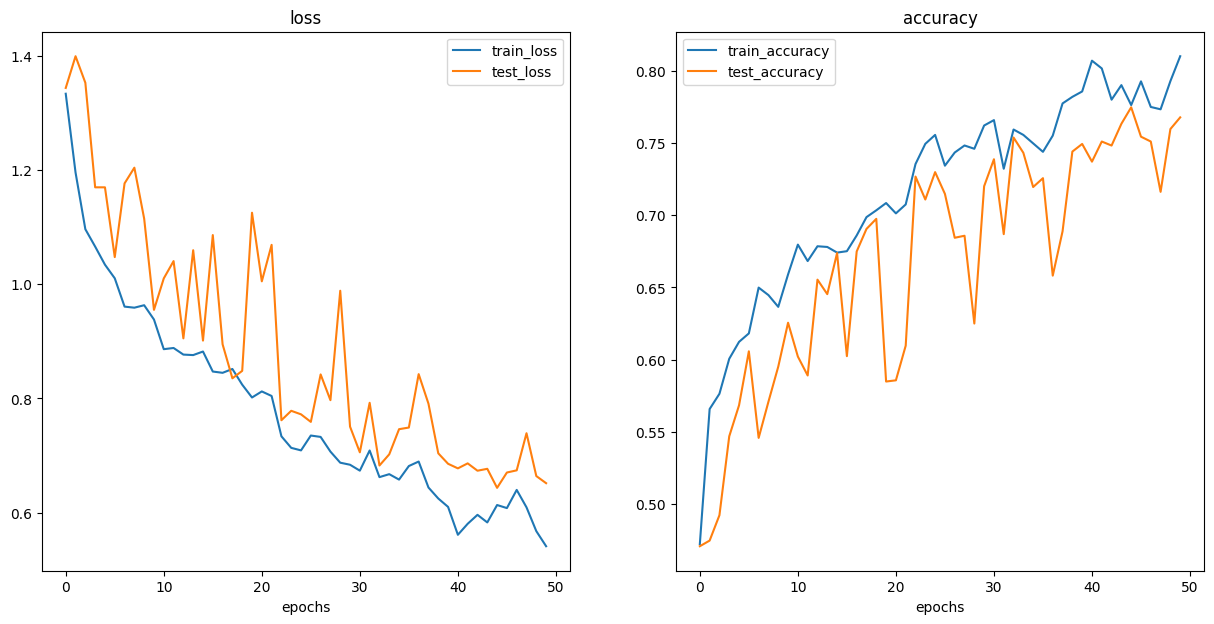

In [ ]:
plot_loss_curves(results)

In [ ]:
# Trying to reach 80% - 85% accuracy

class WasteCNN(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units*2, out_channels=hidden_units*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv_block_3 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units*2, out_channels=hidden_units*4, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*4),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units*4, out_channels=hidden_units*4, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*4),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv_block_4 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units*4, out_channels=hidden_units*8, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*8),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units*8, out_channels=hidden_units*8, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*8),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Classifier with Global Average Pooling (GAP)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(output_size=1), # Reduces 8x8 to 1x1
            nn.Flatten(), # Becomes a vector of length (hidden_units * 4)
            nn.Dropout(p=0.2),
            nn.Linear(in_features=hidden_units*8, out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.conv_block_1(x)
        #print(x.shape)
        x = self.conv_block_2(x)
        #print(x.shape)
        x = self.conv_block_3(x)
        #print(x.shape)
        x = self.conv_block_4(x)
        #print(x.shape)
        x = self.classifier(x)
        #print(x.shape)

        return x

In [ ]:
modelVN = WasteCNN(
    input_shape = 3,
    hidden_units = 32,
    output_shape = len(train_data.classes)
).to(device)

In [ ]:
modelVN(img.to(device))

NameError: name 'img' is not defined

In [ ]:
optimizer = torch.optim.Adam(params = modelVN.parameters(), lr = 0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3)
loss_fn = nn.CrossEntropyLoss()

In [ ]:
results = train(
    epochs = 50,
    model = modelVN,
    train_dataloader = train_dataloader,
    test_dataloader = test_dataloader,
    optimizer = optimizer,
    loss_fn = loss_fn,
    scheduler = scheduler
)

  0%|          | 0/50 [00:00<?, ?it/s]

KeyboardInterrupt: 